# Part II: Polynomial Regression with Two Features

## Objective

Capture nonlinear and interaction effects using polynomial feature engineering and an explicit bias term:

$$\hat{L} = X \cdot w + b$$

### Feature Map

Construct the design matrix using the following features (do not include a constant column of ones):

$$X = [ M, T, M^2, M \cdot T ]$$

---

## Required Tasks

1. **Dataset visualization**: plot L vs M and encode T (color or marker size).
2. **Feature engineering**: build X with NumPy vectorization.
3. **Loss and gradients (vectorized)**: implement MSE and gradients w.r.t. both w and b.
4. **Gradient descent + convergence**: train and plot loss vs iterations.
5. **Feature selection experiment (mandatory)**: compare M1, M2, M3 models.
6. **Cost vs interaction (mandatory)**: vary w_MT and plot cost.
7. **Inference demo (mandatory)**: predict luminosity for a new star.

## Task 1: Dataset and Visualization

**Dataset (Part II - two features):**
- M: stellar mass (in units of solar mass, M⊙)
- T: effective stellar temperature (Kelvin, K)
- L: stellar luminosity (in units of solar luminosity, L⊙)

Plot L vs M and encode T using color or marker size.

Number of examples: m = 10
Stellar Mass M (M☉): [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
Temperature T (K): [3800 4400 5800 6400 6900 7400 7900 8300 8800 9200]
Stellar Luminosity L (L☉): [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]


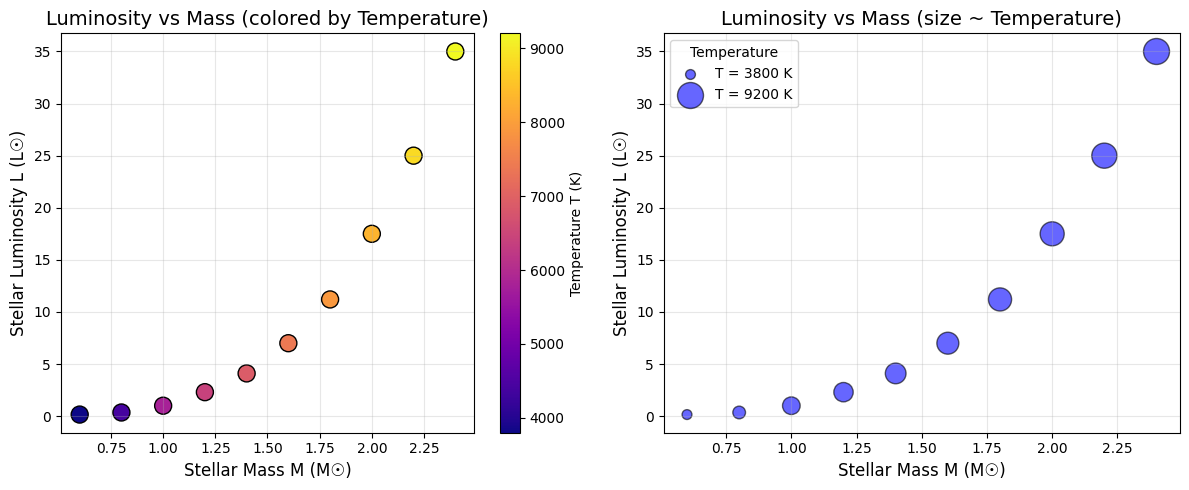

In [1]:
# Task 1: Dataset and Visualization
import numpy as np
import matplotlib.pyplot as plt

# Dataset (Part II - two features)
# M: stellar mass (in units of solar mass, M⊙)
# T: effective stellar temperature (Kelvin, K)
# L: stellar luminosity (in units of solar luminosity, L⊙)

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Number of examples
m = len(M)
print(f"Number of examples: m = {m}")
print(f"Stellar Mass M (M☉): {M}")
print(f"Temperature T (K): {T}")
print(f"Stellar Luminosity L (L☉): {L}")

# Plot L vs M with T encoded as color
plt.figure(figsize=(12, 5))

# Subplot 1: L vs M with T as color
plt.subplot(1, 2, 1)
scatter = plt.scatter(M, L, c=T, cmap='plasma', s=150, edgecolors='black')
plt.colorbar(scatter, label='Temperature T (K)')
plt.xlabel("Stellar Mass M (M☉)", fontsize=12)
plt.ylabel("Stellar Luminosity L (L☉)", fontsize=12)
plt.title("Luminosity vs Mass (colored by Temperature)", fontsize=14)
plt.grid(True, alpha=0.3)

# Subplot 2: L vs M with T as marker size
plt.subplot(1, 2, 2)
# Normalize T for marker size (scale to reasonable range)
sizes = (T - T.min()) / (T.max() - T.min()) * 300 + 50
plt.scatter(M, L, s=sizes, c='blue', alpha=0.6, edgecolors='black')
plt.xlabel("Stellar Mass M (M☉)", fontsize=12)
plt.ylabel("Stellar Luminosity L (L☉)", fontsize=12)
plt.title("Luminosity vs Mass (size ~ Temperature)", fontsize=14)
plt.grid(True, alpha=0.3)

# Add legend for size
for t_val, size_val in [(T.min(), 50), (T.max(), 350)]:
    plt.scatter([], [], s=size_val, c='blue', alpha=0.6, edgecolors='black', 
                label=f'T = {t_val:.0f} K')
plt.legend(title='Temperature', loc='upper left')

plt.tight_layout()
plt.show()

### Observations on the Dataset

**Relationship Patterns:**
- There is a strong **positive correlation** between stellar mass (M) and luminosity (L).
- The relationship is clearly **non-linear** — luminosity increases much faster than mass.
- Temperature (T) also increases with mass, which is consistent with stellar physics: more massive stars have higher surface temperatures.

**Physical Interpretation:**
- More massive stars have higher core pressures and temperatures, leading to:
  1. Faster nuclear fusion rates → higher luminosity
  2. Higher surface temperatures → bluer color
- The data suggests that both M and T contribute to determining L, and there may be **interaction effects** between these features.

**Justification for Polynomial Features:**
- The curvature in the L vs M relationship suggests we need polynomial terms (like $M^2$).
- The correlation between M and T suggests an **interaction term** ($M \times T$) might capture combined effects.

## Task 2: Feature Engineering

Build the design matrix X using NumPy vectorization with the following features:
- M (stellar mass)
- T (stellar temperature)
- M² (mass squared)
- M·T (mass-temperature interaction)

**Do not include a constant column of ones** (the bias b is handled separately).

In [2]:
# Task 2: Feature Engineering

def build_feature_matrix(M, T, model_type='M3'):
    """
    Build design matrix X with polynomial features using NumPy vectorization.
    
    Feature maps:
    - M1: X = [M, T]                    (2 features)
    - M2: X = [M, T, M²]                (3 features)
    - M3: X = [M, T, M², M·T]           (4 features) - Full model
    
    Parameters:
    -----------
    M : np.ndarray
        Stellar mass values
    T : np.ndarray
        Stellar temperature values
    model_type : str
        'M1', 'M2', or 'M3' to select feature set
    
    Returns:
    --------
    X : np.ndarray
        Design matrix (m x n), where n depends on model_type
    feature_names : list
        Names of the features for interpretation
    """
    if model_type == 'M1':
        # Model 1: Linear features only [M, T]
        X = np.column_stack([M, T])
        feature_names = ['M', 'T']
    
    elif model_type == 'M2':
        # Model 2: Add quadratic term [M, T, M²]
        X = np.column_stack([M, T, M**2])
        feature_names = ['M', 'T', 'M²']
    
    elif model_type == 'M3':
        # Model 3: Full polynomial with interaction [M, T, M², M·T]
        X = np.column_stack([M, T, M**2, M * T])
        feature_names = ['M', 'T', 'M²', 'M·T']
    
    else:
        raise ValueError(f"Unknown model_type: {model_type}. Use 'M1', 'M2', or 'M3'.")
    
    return X, feature_names


# Build feature matrices for all three models
X_M1, features_M1 = build_feature_matrix(M, T, 'M1')
X_M2, features_M2 = build_feature_matrix(M, T, 'M2')
X_M3, features_M3 = build_feature_matrix(M, T, 'M3')

print("=" * 60)
print("Feature Engineering Results")
print("=" * 60)

print(f"\nModel M1 - Features: {features_M1}")
print(f"  Shape: {X_M1.shape}")
print(f"  First 3 rows:\n{X_M1[:3]}")

print(f"\nModel M2 - Features: {features_M2}")
print(f"  Shape: {X_M2.shape}")
print(f"  First 3 rows:\n{X_M2[:3]}")

print(f"\nModel M3 - Features: {features_M3}")
print(f"  Shape: {X_M3.shape}")
print(f"  First 3 rows:\n{X_M3[:3]}")

Feature Engineering Results

Model M1 - Features: ['M', 'T']
  Shape: (10, 2)
  First 3 rows:
[[6.0e-01 3.8e+03]
 [8.0e-01 4.4e+03]
 [1.0e+00 5.8e+03]]

Model M2 - Features: ['M', 'T', 'M²']
  Shape: (10, 3)
  First 3 rows:
[[6.0e-01 3.8e+03 3.6e-01]
 [8.0e-01 4.4e+03 6.4e-01]
 [1.0e+00 5.8e+03 1.0e+00]]

Model M3 - Features: ['M', 'T', 'M²', 'M·T']
  Shape: (10, 4)
  First 3 rows:
[[6.00e-01 3.80e+03 3.60e-01 2.28e+03]
 [8.00e-01 4.40e+03 6.40e-01 3.52e+03]
 [1.00e+00 5.80e+03 1.00e+00 5.80e+03]]


In [3]:
# Feature Scaling Function (important for gradient descent convergence)

def feature_scale(X):
    """
    Standardize each feature to have mean 0 and standard deviation 1.
    
    Formula: X_scaled = (X - mean) / std
    
    Parameters:
    -----------
    X : np.ndarray, shape (m, n)
        Design matrix
    
    Returns:
    --------
    X_scaled : np.ndarray, shape (m, n)
        Scaled design matrix
    means : np.ndarray, shape (n,)
        Mean of each feature
    stds : np.ndarray, shape (n,)
        Standard deviation of each feature
    """
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    # Avoid division by zero
    stds = np.where(stds == 0, 1, stds)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds


# Scale the full model (M3) for demonstration
X_M3_scaled, X_M3_means, X_M3_stds = feature_scale(X_M3)

print("Feature Scaling for Model M3:")
print(f"  Feature means: {X_M3_means}")
print(f"  Feature stds:  {X_M3_stds}")
print(f"\nScaled X_M3 (first 3 rows):\n{X_M3_scaled[:3]}")
print(f"\nVerification - Scaled means: {X_M3_scaled.mean(axis=0)}")
print(f"Verification - Scaled stds:  {X_M3_scaled.std(axis=0)}")

Feature Scaling for Model M3:
  Feature means: [1.5000e+00 6.8900e+03 2.5800e+00 1.1304e+04]
  Feature stds:  [5.74456265e-01 1.71548827e+03 1.74770707e+00 6.37191211e+03]

Scaled X_M3 (first 3 rows):
[[-1.5666989  -1.80123645 -1.27023575 -1.41621539]
 [-1.21854359 -1.4514818  -1.11002584 -1.22161132]
 [-0.87038828 -0.63538762 -0.90404166 -0.86379095]]

Verification - Scaled means: [-3.33066907e-16  6.66133815e-17  2.44249065e-16  4.44089210e-17]
Verification - Scaled stds:  [1. 1. 1. 1.]


## Task 3: Loss and Gradients (Vectorized)

Implement using NumPy vectorization:
- **MSE Loss**: $J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{L}_i - L_i)^2$
- **Gradients**: $\frac{\partial J}{\partial w}$ and $\frac{\partial J}{\partial b}$

Where: $\hat{L} = X \cdot w + b$

In [4]:
# Task 3: Loss and Gradients (Vectorized)

def predict_poly(X, w, b):
    """
    Vectorized prediction function for polynomial regression.
    
    Model: L_hat = X @ w + b
    
    Parameters:
    -----------
    X : np.ndarray, shape (m, n)
        Design matrix (feature-engineered)
    w : np.ndarray, shape (n,)
        Weight vector
    b : float
        Bias term
    
    Returns:
    --------
    L_hat : np.ndarray, shape (m,)
        Predicted luminosity values
    """
    return X @ w + b


def compute_cost_poly(X, L, w, b):
    """
    Compute the Mean Squared Error (MSE) cost function (vectorized).
    
    J(w, b) = (1 / 2m) * (L_hat - L)ᵀ(L_hat - L)
    
    Parameters:
    -----------
    X : np.ndarray, shape (m, n)
        Design matrix
    L : np.ndarray, shape (m,)
        True luminosity values
    w : np.ndarray, shape (n,)
        Weight vector
    b : float
        Bias term
    
    Returns:
    --------
    cost : float
        The MSE cost value
    """
    m = X.shape[0]
    L_hat = predict_poly(X, w, b)
    errors = L_hat - L
    cost = (errors @ errors) / (2 * m)
    return cost


def compute_gradients_poly(X, L, w, b):
    """
    Compute gradients of J with respect to w and b (vectorized).
    
    Vectorized formulas:
        ∂J/∂w = (1/m) * Xᵀ(L_hat - L)
        ∂J/∂b = (1/m) * Σ(L_hat - L)
    
    Parameters:
    -----------
    X : np.ndarray, shape (m, n)
        Design matrix
    L : np.ndarray, shape (m,)
        True luminosity values
    w : np.ndarray, shape (n,)
        Weight vector
    b : float
        Bias term
    
    Returns:
    --------
    dj_dw : np.ndarray, shape (n,)
        Gradient with respect to w
    dj_db : float
        Gradient with respect to b
    """
    m = X.shape[0]
    L_hat = predict_poly(X, w, b)
    errors = L_hat - L
    
    # Vectorized gradient computation
    dj_dw = (X.T @ errors) / m
    dj_db = np.sum(errors) / m
    
    return dj_dw, dj_db


# Test the functions with the full model (M3)
print("=" * 60)
print("Testing Loss and Gradient Functions")
print("=" * 60)

# Initialize parameters
n_features = X_M3_scaled.shape[1]
w_test = np.zeros(n_features)
b_test = 0.0

# Test prediction
L_pred_test = predict_poly(X_M3_scaled, w_test, b_test)
print(f"\nTest predictions (first 5) with w=0, b=0: {L_pred_test[:5]}")

# Test cost
cost_test = compute_cost_poly(X_M3_scaled, L, w_test, b_test)
print(f"Cost with w=0, b=0: {cost_test:.4f}")

# Test gradients
dj_dw_test, dj_db_test = compute_gradients_poly(X_M3_scaled, L, w_test, b_test)
print(f"\nGradients at w=0, b=0:")
print(f"  ∂J/∂w = {dj_dw_test}")
print(f"  ∂J/∂b = {dj_db_test:.4f}")

Testing Loss and Gradient Functions

Test predictions (first 5) with w=0, b=0: [0. 0. 0. 0. 0.]
Cost with w=0, b=0: 117.6967

Gradients at w=0, b=0:
  ∂J/∂w = [-10.41506616  -9.59761737 -10.99417651 -10.71881702]
  ∂J/∂b = -10.3600


## Task 4: Gradient Descent + Convergence

Train the model and plot **loss vs iterations**.

In [ ]:
# Task 4: Gradient Descent + Convergence

def gradient_descent_poly(X, L, w_init, b_init, learning_rate, num_iterations):
    """
    Gradient descent for polynomial regression
    """
    # TODO: Implement gradient descent
    # TODO: Track loss history for convergence plot
    pass

# TODO: Train the model
# TODO: Plot loss vs iterations

## Task 5: Feature Selection Experiment (Mandatory)

Compare three models with different feature sets:

| Model | Features |
|-------|----------|
| **M1** | X = [M, T] |
| **M2** | X = [M, T, M²] |
| **M3** | X = [M, T, M², M·T] |

For each model, report:
- Final loss
- Learned parameters
- Predicted vs actual plot (inline)

In [ ]:
# Task 5: Feature Selection Experiment (Mandatory)

# Model M1: X = [M, T]
# TODO: Build feature matrix for M1
# TODO: Train model M1
# TODO: Report final loss, learned parameters
# TODO: Plot predicted vs actual

# Model M2: X = [M, T, M^2]
# TODO: Build feature matrix for M2
# TODO: Train model M2
# TODO: Report final loss, learned parameters
# TODO: Plot predicted vs actual

# Model M3: X = [M, T, M^2, M*T]
# TODO: Build feature matrix for M3
# TODO: Train model M3
# TODO: Report final loss, learned parameters
# TODO: Plot predicted vs actual

## Task 6: Cost vs Interaction (Mandatory)

For the full model (M3), vary the interaction coefficient $w_{MT}$ across a reasonable range while keeping the other parameters fixed (e.g., at their trained values).

- Plot **cost vs $w_{MT}$**
- Explain what it indicates about **interaction importance**

In [ ]:
# Task 6: Cost vs Interaction (Mandatory)

# TODO: Use trained parameters from M3 as fixed values
# TODO: Vary w_MT across a reasonable range
# TODO: Compute cost for each w_MT value
# TODO: Plot cost vs w_MT
# TODO: Explain what this indicates about interaction importance

## Task 7: Inference Demo (Mandatory)

Predict luminosity for a new star:
- **M = 1.3** (solar masses)
- **T = 6600** (Kelvin)

Comment on the **reasonableness** of the prediction.

In [ ]:
# Task 7: Inference Demo (Mandatory)

# New star parameters
M_new = 1.3  # solar masses
T_new = 6600  # Kelvin

# TODO: Build feature vector for the new star
# TODO: Predict luminosity using trained model (M3)
# TODO: Comment on the reasonableness of the prediction